In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

images = {
    "kid": 'kid1.jpg',
    "coins": 'Coins.png',
    "bird": 'bird.png',
    "butterfly": 'Butterfly.jpg'
}

def show_result(original, processed, title="Edge Detection"):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

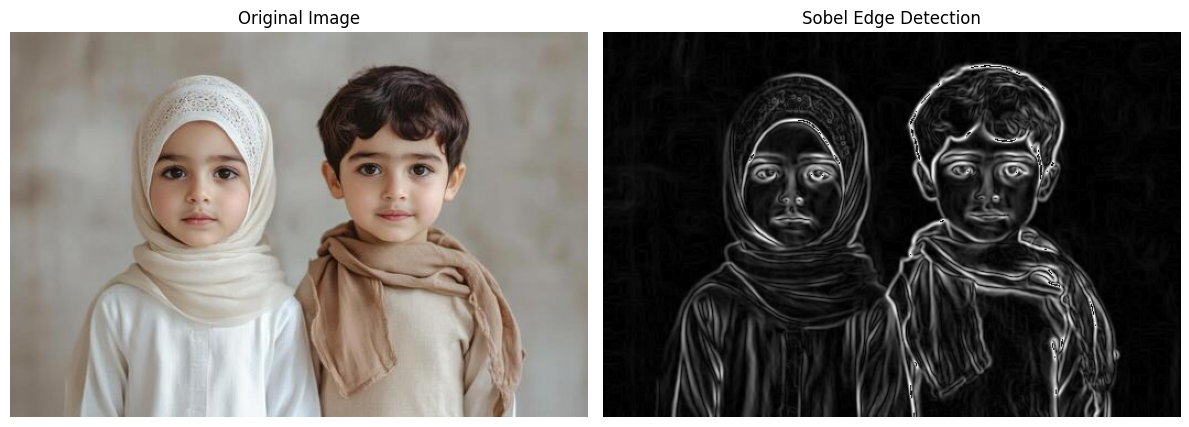

In [4]:
#Load image
img = cv2.imread(images['kid'])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Apply Ggaussian blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

#Apply Sobel filter
sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

#Magnitude and normalize
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_final = np.uint8(np.absolute(sobel_combined))

show_result(img, sobel_final, "Sobel Edge Detection")

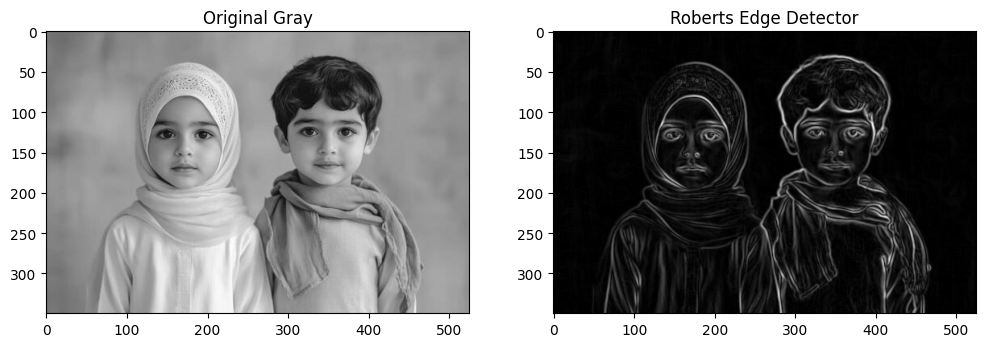

In [5]:
#Load image in grayscale
image = cv2.imread(images['kid'], 0)
blurred = cv2.GaussianBlur(image, (5, 5), 0)

#Define Robertscross kernels
kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float64)

#Apply convolution
roberts_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
roberts_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)

#Calculate Magnitude
roberts_combined = cv2.magnitude(roberts_x, roberts_y)
roberts_final = np.uint8(np.absolute(roberts_combined))

#results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Gray')
plt.subplot(1, 2, 2), plt.imshow(roberts_final, cmap='gray'), plt.title('Roberts Edge Detector')
plt.show()

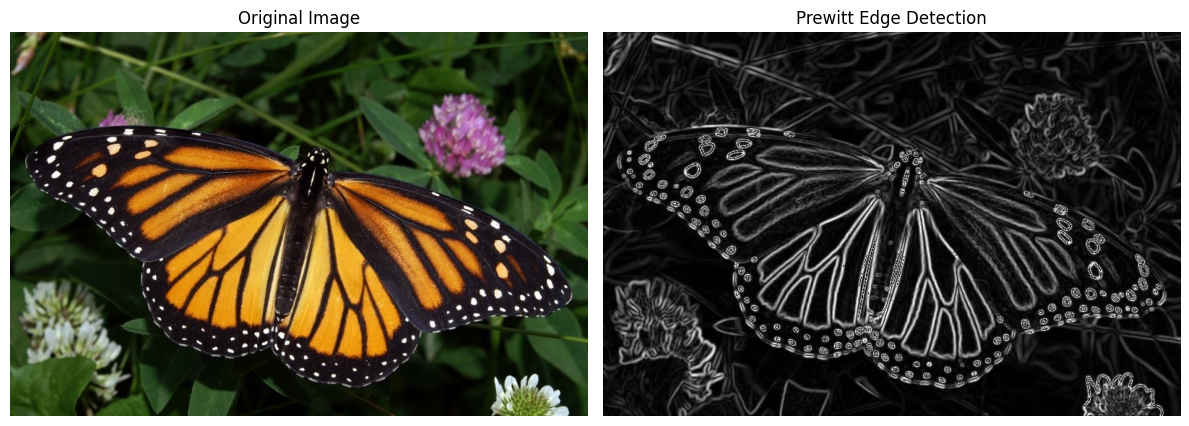

In [6]:
img = cv2.imread(images['butterfly'])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Define Prewitt Kernels manually
kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64)
kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float64)

prewitt_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)

prewitt_combined = cv2.magnitude(prewitt_x, prewitt_y)
prewitt_final = np.uint8(np.absolute(prewitt_combined))

show_result(img, prewitt_final, "Prewitt Edge Detection")

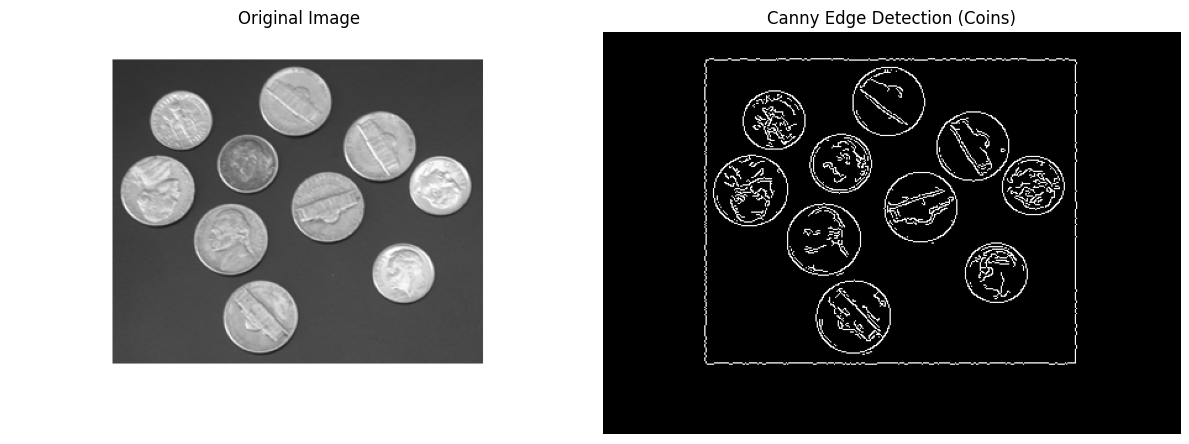

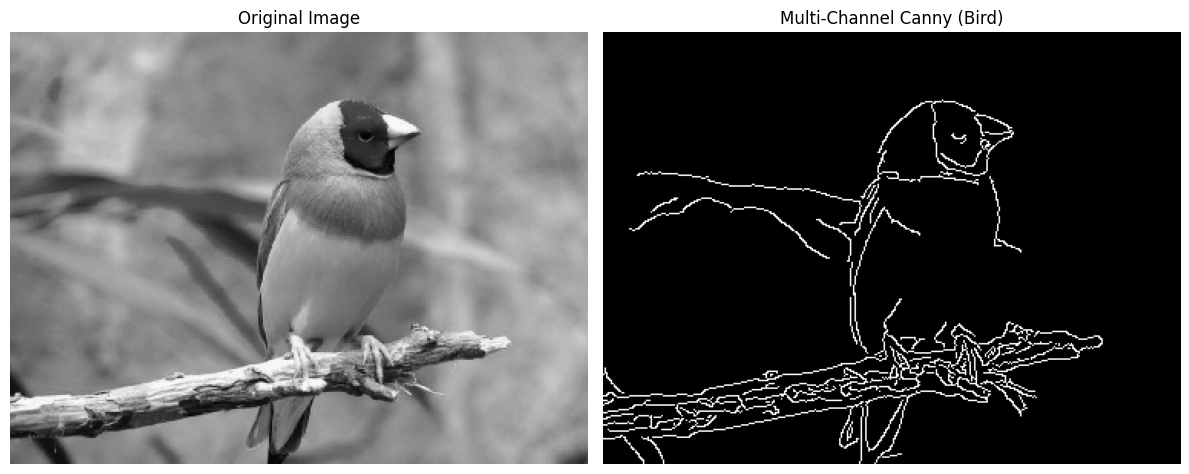

In [7]:
#Single Channel canny
img = cv2.imread(images['coins'])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny_edges = cv2.Canny(gray, 100, 200)

show_result(img, canny_edges, "Canny Edge Detection (Coins)")

#Multi-Channel canny
def best_color_edge_detector(image_path):
    img = cv2.imread(image_path)
    channels = cv2.split(img)
    edge_maps = []
    for ch in channels:
        blurred = cv2.GaussianBlur(ch, (5, 5), 0)
        edges = cv2.Canny(blurred, 50, 150)
        edge_maps.append(edges)
    
    
    combined_edges = cv2.bitwise_or(edge_maps[0], cv2.bitwise_or(edge_maps[1], edge_maps[2]))
    return img, combined_edges

original, multi_canny = best_color_edge_detector(images['bird'])
show_result(original, multi_canny, "Multi-Channel Canny (Bird)")

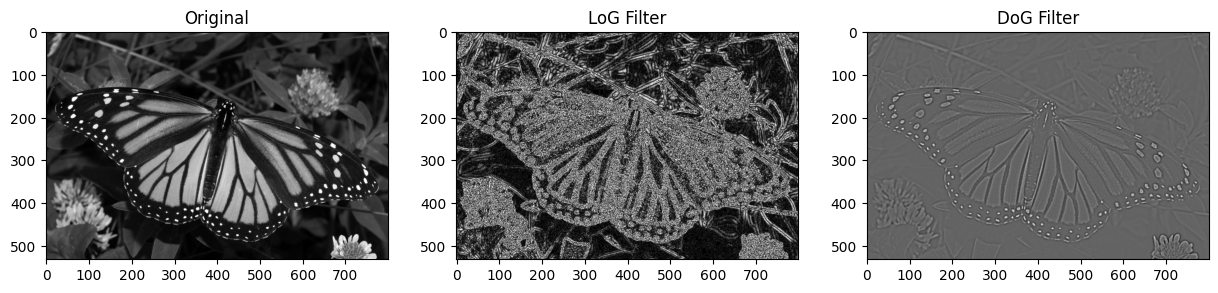

In [8]:
#Load image
img_gray = cv2.imread(images['butterfly'], 0)

#LoG Filter
blurred_log = cv2.GaussianBlur(img_gray, (5, 5), 0)
laplacian = cv2.Laplacian(blurred_log, cv2.CV_64F, ksize=5)
log_final = np.uint8(np.absolute(laplacian))

#DoG Filter
blur_narrow = cv2.GaussianBlur(img_gray, (0, 0), sigmaX=1.0)
blur_wide = cv2.GaussianBlur(img_gray, (0, 0), sigmaX=2.0)
dog = blur_narrow.astype(np.float32) - blur_wide.astype(np.float32)
dog_normalized = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

#visual results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(log_final, cmap='gray'), plt.title('LoG Filter')
plt.subplot(1, 3, 3), plt.imshow(dog_normalized, cmap='gray'), plt.title('DoG Filter')
plt.show()

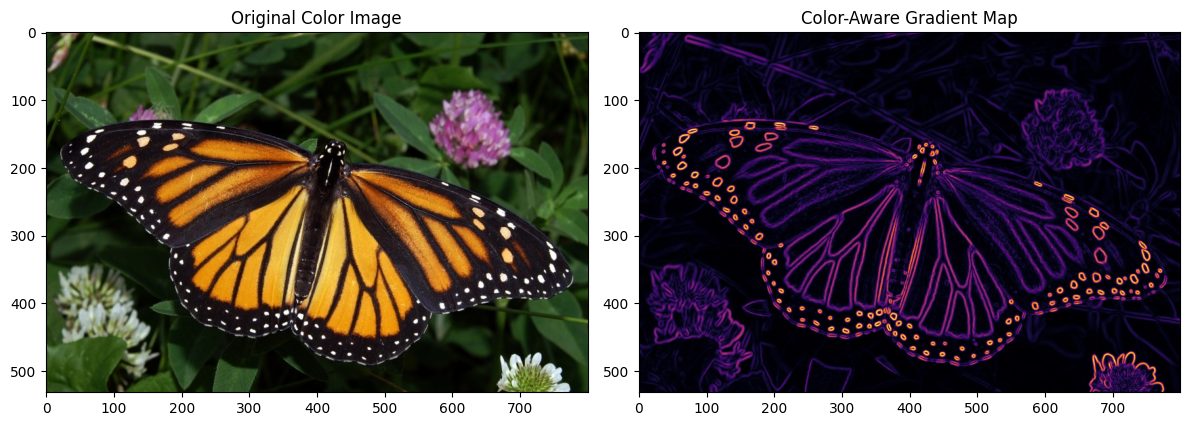

In [9]:
#Load real world color
image = cv2.imread(images['butterfly'])

#Split image into R, G, B components
b, g, r = cv2.split(image)

def get_channel_gradient(channel):
    blurred = cv2.GaussianBlur(channel, (3, 3), 0)
    gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    return cv2.magnitude(gx, gy)

#Compute gradients
grad_b = get_channel_gradient(b)
grad_g = get_channel_gradient(g)
grad_r = get_channel_gradient(r)

#Combine gradients
combined_gradient = np.sqrt(grad_b**2 + grad_g**2 + grad_r**2)

color_edges = cv2.normalize(combined_gradient, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

#results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title('Original Color Image')
plt.subplot(1, 2, 2), plt.imshow(color_edges, cmap='inferno'), plt.title('Color-Aware Gradient Map')
plt.tight_layout()
plt.show()